# Decision Tree with NumPy
CART with Gini impurity — vectorised split search, Gini-weighted importance.
Model saved to `models/dt_numpy.json`.

## 1. Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, os
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

iris        = load_iris()
features    = list(iris.feature_names)
class_names = list(iris.target_names)
X           = iris.data
y           = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}  |  Features: {len(features)}")

Train: 120  |  Test: 30  |  Features: 4


## 2. Vectorised Gini & Split Search

The scratch version loops over every sample for every threshold.
NumPy lets us use **boolean masking** and **vectorised ops** to evaluate
all thresholds for a given feature in one shot.

In [2]:
def gini(y):
    """Gini impurity: 1 - sum(p_k^2). Vectorised."""
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    p = counts / len(y)
    return 1.0 - float(np.sum(p ** 2))


def best_split_np(X, y):
    """
    For each feature: sort unique values as candidate thresholds,
    compute weighted Gini for each split using boolean masks.
    Returns: (best_feature, best_threshold, best_weighted_gini)
    """
    n              = len(y)
    best_gini      = float('inf')
    best_feat      = None
    best_threshold = None

    for feat in range(X.shape[1]):
        col         = X[:, feat]
        thresholds  = np.unique(col)[:-1]       # skip the max value — right side would be empty

        for thresh in thresholds:
            left_mask  = col <= thresh
            right_mask = ~left_mask
            n_l, n_r   = left_mask.sum(), right_mask.sum()

            if n_l == 0 or n_r == 0:
                continue

            w_gini = (n_l * gini(y[left_mask]) + n_r * gini(y[right_mask])) / n

            if w_gini < best_gini:
                best_gini      = w_gini
                best_feat      = feat
                best_threshold = thresh

    return best_feat, best_threshold, best_gini

## 3. Node & Tree

In [3]:
class Node:
    __slots__ = ['feature','threshold','left','right','value','gini','n_samples',
                 'class_counts','impurity_decrease']

    def __init__(self, feature=None, threshold=None, left=None, right=None,
                 value=None, gini=0.0, n_samples=0, class_counts=None, impurity_decrease=0.0):
        self.feature          = feature
        self.threshold        = threshold
        self.left             = left
        self.right            = right
        self.value            = value
        self.gini             = gini
        self.n_samples        = n_samples
        self.class_counts     = class_counts if class_counts is not None else {}
        self.impurity_decrease= impurity_decrease     # for importance calculation

    @property
    def is_leaf(self):
        return self.value is not None


def grow_tree(X, y, depth=0, max_depth=10, min_samples_split=2):
    n          = len(y)
    classes, cnts = np.unique(y, return_counts=True)
    majority   = classes[np.argmax(cnts)]
    node_gini  = gini(y)
    class_dict = dict(zip(classes.tolist(), cnts.tolist()))

    if depth >= max_depth or n < min_samples_split or len(classes) == 1:
        return Node(value=int(majority), gini=node_gini, n_samples=n, class_counts=class_dict)

    feat, thresh, w_gini = best_split_np(X, y)

    if feat is None:
        return Node(value=int(majority), gini=node_gini, n_samples=n, class_counts=class_dict)

    left_mask  = X[:, feat] <= thresh
    impurity_dec = node_gini - w_gini     # information gain via Gini

    return Node(
        feature           = feat,
        threshold         = float(thresh),
        gini              = node_gini,
        n_samples         = n,
        class_counts      = class_dict,
        impurity_decrease = impurity_dec,
        left  = grow_tree(X[left_mask],  y[left_mask],  depth+1, max_depth, min_samples_split),
        right = grow_tree(X[~left_mask], y[~left_mask], depth+1, max_depth, min_samples_split)
    )


def predict_one(x, node):
    if node.is_leaf:
        return node.value
    return predict_one(x, node.left) if x[node.feature] <= node.threshold else predict_one(x, node.right)


def predict(X, root):
    return np.array([predict_one(x, root) for x in X])


def predict_proba(X, root, n_classes):
    """Return class probability matrix (n, n_classes) using leaf class counts."""
    def proba_one(x, node):
        if node.is_leaf:
            total = sum(node.class_counts.values())
            return [node.class_counts.get(k, 0) / total for k in range(n_classes)]
        return proba_one(x, node.left) if x[node.feature] <= node.threshold else proba_one(x, node.right)
    return np.array([proba_one(x, root) for x in X])

## 4. Train

In [4]:
MAX_DEPTH = 4
tree      = grow_tree(X_train, y_train, max_depth=MAX_DEPTH)
print(f"Root split: {features[tree.feature]} <= {tree.threshold:.3f}  |  n={tree.n_samples}")

Root split: petal length (cm) <= 1.900  |  n=120


## 5. Text Tree Printer

In [5]:
def print_tree(node, feature_names, class_names, indent='', last=True):
    connector = '└── ' if last else '├── '
    if node.is_leaf:
        print(f"{indent}{connector}LEAF: {class_names[node.value]}  "
              f"(n={node.n_samples}, gini={node.gini:.3f})")
    else:
        print(f"{indent}{connector}[{feature_names[node.feature]} <= {node.threshold:.3f}]  "
              f"n={node.n_samples}, gini={node.gini:.3f}")
        child_indent = indent + ('    ' if last else '│   ')
        print_tree(node.left,  feature_names, class_names, child_indent, False)
        print_tree(node.right, feature_names, class_names, child_indent, True)

print_tree(tree, features, class_names)

└── [petal length (cm) <= 1.900]  n=120, gini=0.667
    ├── LEAF: setosa  (n=40, gini=0.000)
    └── [petal width (cm) <= 1.600]  n=80, gini=0.500
        ├── [petal length (cm) <= 4.900]  n=42, gini=0.133
        │   ├── LEAF: versicolor  (n=38, gini=0.000)
        │   └── [sepal length (cm) <= 6.000]  n=4, gini=0.375
        │       ├── LEAF: versicolor  (n=2, gini=0.500)
        │       └── LEAF: virginica  (n=2, gini=0.000)
        └── [petal length (cm) <= 4.800]  n=38, gini=0.051
            ├── [sepal width (cm) <= 2.800]  n=3, gini=0.444
            │   ├── LEAF: virginica  (n=2, gini=0.000)
            │   └── LEAF: versicolor  (n=1, gini=0.000)
            └── LEAF: virginica  (n=35, gini=0.000)


## 6. Evaluation

In [6]:
y_pred_train = predict(X_train, tree)
y_pred_test  = predict(X_test,  tree)

print(f"Train Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Test  Accuracy: {accuracy_score(y_test,  y_pred_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=class_names))

Train Accuracy: 0.9917
Test  Accuracy: 0.9333

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 7. Confusion Matrix

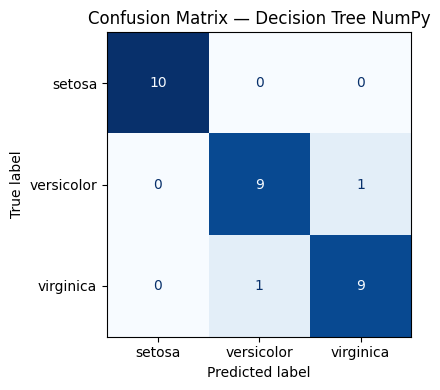

In [7]:
cm   = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Decision Tree NumPy')
plt.tight_layout(); plt.show()

## 8. Feature Importance (Gini-Weighted Impurity Decrease)

The standard sklearn importance formula — each split contributes:
$$\text{importance}_j \mathrel{+}= \frac{n_t}{n} \cdot \Delta G_t$$
where $n_t$ = samples at node $t$, $\Delta G_t$ = Gini decrease from the split.

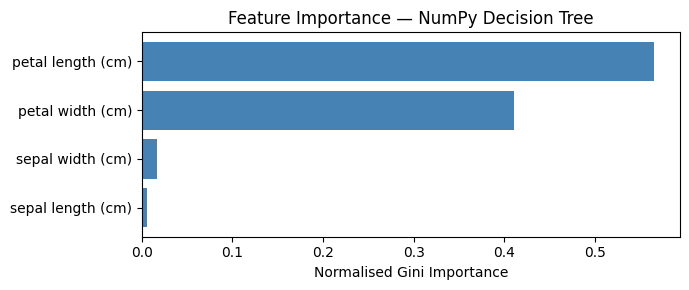

In [8]:
def feature_importance(node, n_total, n_features, scores=None):
    if scores is None:
        scores = np.zeros(n_features)
    if not node.is_leaf:
        scores[node.feature] += (node.n_samples / n_total) * node.impurity_decrease
        feature_importance(node.left,  n_total, n_features, scores)
        feature_importance(node.right, n_total, n_features, scores)
    return scores

n_total  = len(y_train)
imp      = feature_importance(tree, n_total, len(features))
imp      = imp / imp.sum()          # normalise to sum to 1

order = np.argsort(imp)
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh([features[i] for i in order], imp[order], color='steelblue')
ax.set_xlabel('Normalised Gini Importance')
ax.set_title('Feature Importance — NumPy Decision Tree')
plt.tight_layout(); plt.show()

## 9. Depth vs Accuracy

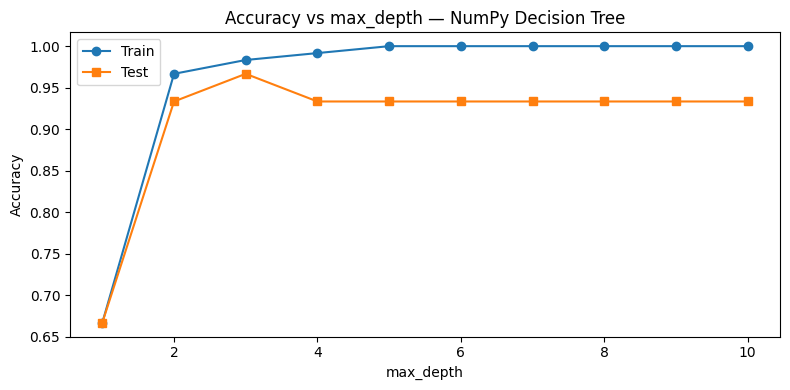

In [9]:
depths     = range(1, 11)
tr_accs, te_accs = [], []
for d in depths:
    t = grow_tree(X_train, y_train, max_depth=d)
    tr_accs.append(accuracy_score(y_train, predict(X_train, t)))
    te_accs.append(accuracy_score(y_test,  predict(X_test,  t)))

plt.figure(figsize=(8, 4))
plt.plot(depths, tr_accs, marker='o', label='Train')
plt.plot(depths, te_accs, marker='s', label='Test')
plt.xlabel('max_depth'); plt.ylabel('Accuracy')
plt.title('Accuracy vs max_depth — NumPy Decision Tree')
plt.legend(); plt.tight_layout(); plt.show()

## 10. Save Model to `models/`

In [10]:
def node_to_dict(node):
    if node.is_leaf:
        return {'leaf': True, 'value': int(node.value),
                'gini': node.gini, 'n_samples': node.n_samples,
                'class_counts': {str(k): int(v) for k, v in node.class_counts.items()}}
    return {'leaf': False, 'feature': int(node.feature), 'threshold': node.threshold,
            'gini': node.gini, 'n_samples': node.n_samples,
            'class_counts': {str(k): int(v) for k, v in node.class_counts.items()},
            'impurity_decrease': node.impurity_decrease,
            'left': node_to_dict(node.left), 'right': node_to_dict(node.right)}

model_data = {
    'feature_names': features,
    'class_names':   class_names,
    'max_depth':     MAX_DEPTH,
    'split':         {'test_size': 0.2, 'random_state': 42, 'stratify': True},
    'tree':          node_to_dict(tree)
}
save_path = '../Models/dt_numpy.json'
with open(save_path, 'w') as f:
    json.dump(model_data, f)

size_kb = os.path.getsize(save_path) / 1024
print(f"Saved → {save_path}  ({size_kb:.1f} KB)")

Saved → ../Models/dt_numpy.json  (1.9 KB)
